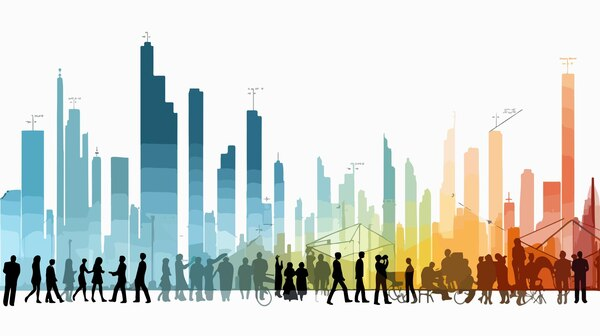

<span style="color:green; font-size:24px; font-weight:bold;">
PROYECTO EDA: 
</span>



<span style="color:green; font-size:30px; font-weight:bold;">
LA DEMOGRAFÍA DE EUSKADI: ANÁLISIS DE PARÁMETROS BÁSICOS y EVOLUCIÓN RECIENTE
</span>

El estudio planteado tiene como <u>principal objetivo</u> llevar a cabo una aproximación a la evolución reciente de la estructura poblacional del País Vasco.

En las últimas décadas se han producido importantes cambios en la estructura, composición y dinámicas poblacionales de Euskadi. El objetivo es recoger algunos datos relevantes relacionados con algunos de los principales parámetros que explican la dinámica demográfica de la sociedad vasca, destacando los cambios más importantes y aquellos fenómenos que pueden venir a explicar tales cambios.

Algunos de los <u>aspectos a analizar</u>:

- Tamaño poblacional. Número de residentes por edad en Euskadi y evolución en las últimas décadas.
- Movimiento natural de la población: evolución en número de nacimientos y defunciones en las últimas décadas, prestando especial atención a las dinámicas relacionadas con la natalidad (nacimientos, fecundidad).
- Movimientos migratorios. Valoración del impacto que la entrada de población extranjera está teniendo en la estructura de población de Euskadi, prestando especial atención a las diferencias en el comportamiento en relación con la natalidad.
- Previsible evolución de la natalidad en los próximos años, atendiendo a la actual estructura poblacional.

Principales <u>fuentes de información</u> utilizadas: 

INE (Instituto Nacional de Estadística):
- Estadística Continua de Población (población a 1 de enero de cada año)
- Estadística de Nacimientos
- Indicadores de Natalidad
- Indicadores de Fecundidad
- Estadística de Defunciones

EUSTAT (Instituto Vasco de Estadística):
- Estadística de movimientos migratorios
- Microdatos de la Estadística de Nacimientos





<span style="color:green; font-size:24px; font-weight:bold;">
BASES DE DATOS A UTILIZAR: 
</span>

In [16]:
import numpy as np
import pandas as pd


<span style="color:green; font-size:16px; font-weight:bold;">
BASE DE DATOS DE ELABORACIÓN PROPIA A PARTIR DE DESCARGA DE DATOS PROCEDENTES DEL INE Y EL EUSTAT:
</span>

In [17]:
ine = pd.read_csv(r"./ine_original_2.csv", sep=",", decimal=",", encoding="latin1")
ine

,Parametro,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Total_Nacimientos,39646.0,41100.0,38806.0,35657.0,31835.0,28812.0,27255.0,25670.0,23920.0,...,18247.0,17077.0,16100.0,15449.0,14743.0,14276.0,13663.0,13462.0,12950.0,NaN
1,Nac_Esp_Todaslasedades,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15156.0,14102.0,12920.0,12127.0,11452.0,11215.0,10510.0,10061.0,9511.0,NaN
2,Nac_Esp_Menosde15anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,2.0,2.0,2.0,3.0,1.0,NaN,NaN
3,Nac_Esp_15a19anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,140.0,124.0,89.0,107.0,99.0,99.0,100.0,102.0,63.0,NaN
4,Nac_Esp_20a24anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,411.0,369.0,359.0,376.0,339.0,305.0,335.0,324.0,333.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,Pob_Ext_Mujeres_65a69anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1645.0,1853.0,2062.0,2338.0,2742.0,3008.0,3309.0,3800.0,4311.0,4793.0
406,Pob_Ext_Mujeres_70a74anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,970.0,1053.0,1187.0,1329.0,1524.0,1697.0,1927.0,2223.0,2518.0,2962.0
407,Pob_Ext_Mujeres_75a79anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,803.0,825.0,816.0,854.0,875.0,956.0,1041.0,1218.0,1421.0,1626.0
408,Pob_Ext_Mujeres_80a84anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,431.0,421.0,512.0,558.0,636.0,683.0,714.0,739.0,804.0,880.0


In [43]:
ine_comp = pd.read_csv(r"./ine_original_serie_completa.csv", sep=",", decimal=",", encoding="latin1")
ine_comp

,Parametros,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total_Nacimientos,39646.00,41100.00,38806.00,35657.00,31835.00,28812.00,27255.00,25670.00,23920.00,...,18849.00,18247.00,17077.00,16100.00,15449.00,14743.00,14276.00,13663.00,13462.00,12950.00
1,Total_Defunciones,14699.00,14615.00,14523.00,14235.00,14180.00,14254.00,14628.00,14157.00,14853.00,...,21511.00,21224.00,21634.00,21763.00,21566.00,24252.00,23086.00,24203.00,22328.00,22397.00
2,Saldo_Vegetativo,24947.00,26485.00,24283.00,21422.00,17655.00,14558.00,12627.00,11513.00,9067.00,...,-2662.00,-2977.00,-4557.00,-5663.00,-6117.00,-9509.00,-8810.00,-10540.00,-8866.00,-9447.00
3,Tasa_Global_Fec_Total,80.11,81.99,76.41,69.29,61.00,54.46,51.03,47.93,44.61,...,40.71,39.86,37.60,35.58,34.08,32.49,31.82,30.62,30.10,28.91
4,Indicador_Coy_Fecund_Ambas nacionalidades,2.78,2.84,2.65,2.39,2.09,1.86,1.73,1.62,1.50,...,1.37,1.37,1.32,1.28,1.25,1.21,1.20,1.16,1.15,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,Pob_Mujeres_65a69anios,35478.00,36439.00,36995.00,37671.00,38364.00,39023.00,39109.00,39271.00,39527.00,...,67100.00,66794.00,66761.00,67525.00,67377.00,67505.00,68496.00,70074.00,71865.00,73855.00
300,Pob_Mujeres_70a74anios,28104.00,28260.00,29746.00,30533.00,31364.00,32341.00,33311.00,33871.00,34800.00,...,54850.00,57144.00,59804.00,62264.00,63846.00,64847.00,64497.00,64375.00,64975.00,64761.00
301,Pob_Mujeres_75a79anios,17910.00,19452.00,19855.00,21124.00,22179.00,23661.00,24225.00,25479.00,26211.00,...,47040.00,46843.00,45120.00,45155.00,48133.00,51823.00,53855.00,56248.00,58434.00,59997.00
302,Pob_Mujeres_80a84anios,10406.00,10818.00,11560.00,11817.00,12616.00,12872.00,14250.00,14833.00,15855.00,...,47689.00,47554.00,48164.00,46640.00,44341.00,41647.00,41533.00,40016.00,39982.00,42683.00


<span style="color:green; font-size:16px; font-weight:bold;">
FICHEROS DE MICRODATOS (ESTADISTICA DE NACIMIENTOS DEL EUSTAT):
</span>

In [19]:
eustat = pd.read_csv(r"./fichero_final_nac_2024.csv", sep=",", encoding="latin1")
eustat

,CODMUN_INS,PAE_DIAI,PAE_MESI,PAE_ANOI,PAE_DIAN,PAE_MESN,PAE_ANON,PAE_LNAC,PAE_ASSN,PAE_MULT,...,ORDNA,PAE_EDADM1,PAE_EDAMA2,PAE_EDAMA4,PAE_PROMA1,PAE_DURMAT,PAE_EDAPA2,PAE_EDAPA4,PAE_PROPA1,PAE_PESO
0,20999,17.0,10.0,2024.0,14,10,2024,2,1,1,...,1.0,NaN,37,2,2,NaN,NaN,1,NaN,3040
1,20055,22.0,7.0,2024.0,18,7,2024,2,1,1,...,1.0,NaN,43,2,3,NaN,NaN,1,NaN,3470
2,48020,19.0,6.0,2024.0,14,6,2024,2,1,1,...,2.0,NaN,30,1,3,NaN,NaN,1,NaN,3460
3,20045,30.0,1.0,2024.0,26,1,2024,2,1,1,...,1.0,NaN,20,1,2,NaN,NaN,1,NaN,2580
4,1059,3.0,12.0,2024.0,28,11,2024,2,1,1,...,1.0,NaN,15,2,4,NaN,NaN,1,NaN,2600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12982,48020,30.0,5.0,2024.0,27,5,2024,2,1,1,...,2.0,NaN,21,2,5,NaN,21.0,1,4.0,3200
12983,48020,12.0,4.0,2024.0,9,4,2024,2,1,1,...,1.0,29.0,34,2,2,5.0,33.0,2,4.0,2670
12984,20069,23.0,8.0,2024.0,2,8,2024,2,1,1,...,2.0,38.0,38,1,3,0.0,33.0,2,3.0,3600
12985,48020,26.0,12.0,2024.0,16,12,2024,2,1,1,...,1.0,NaN,38,2,1,NaN,36.0,1,4.0,3200


<span style="color:green; font-size:24px; font-weight:bold;">
HIPÓTESIS: 
</span>


Las <u>hipótesis preliminares</u> a contrastar a través del análisis de los datos planteados son las siguientes:
1. La población de Euskadi está en un claro proceso de envejecimiento.

2. Pese a estar experimentando un proceso de envejecimiento, la población de Euskadi crece en los últimos años, si bien este crecimiento se explica por la entrada de población (proceso inmigratorio), no así por crecimiento natural de la población (natalidad).

3. La entrada de población de origen extranjero está impactando de diversas maneras en la estructura poblacional, entre ellas contribuyendo al rejuvenecimiento de la misma,  
3.1. por la incorporación de población joven que modifica la pirámide poblacional,  
3.2. y por la introducción de pautas de natalidad diferentes a las de la población local.

4. Tras más de una década de caída en la natalidad, en los próximos años es previsible se produzca un ligero incremento de la misma,  si bien este incremento será moderado y breve en el tiempo.

<span style="color:green; font-size:24px; font-weight:bold;">
INICIO DEL TRABAJO:   
1_TRATAMIENTO/DEPURACIÓN DE LOS DATASET 
</span>

Iniciamos a priori el trabajo con las dos bases de datos creadas de la descarga realizada de la página del Instituto Nacional de Estadística, quedando la utilización del fichero de microdatos del Eustat supeditado a los datos obtenidos de la fuente principal (INE).

Se trabaja con dos bases de datos: 
1. ine_original_2.csv (da lugar al dataset "ine")
2. ine_original_serie_completa.csv (da lugar al dataset "ine_comp")

Ambas recogen información fundamental para la realización del análisis, relativa a población, natalidad, mortalidad,..., si bien se mantiene en bases separadas por la diferencia de los periodos contemplados: 
- En la primera se produce discontinuidad y ruptura en los periodos de información recogida, lo que impide disponer de información para todo el periodo considerado (1975-2024). 
- En la segunda base (ine_original_serie_completa.csv) se recogen aquellos indicadores de los que se dispone información para todo el periodo, que nos permite tener una visión más global/de largo recorrido sobre la evolución reciente de la población de Euskadi.

En este sentido, el primer trabajo a realizar será el de depurar la base 1 (ine_original_2.csv) para la eliminación de aquellas variables/columnas con valores perdidos que impidirían el análisis del conjunto de los datos.

In [20]:
ine.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 52 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0    Parametro  410 non-null    str    
 1   1975        268 non-null    float64
 2   1976        268 non-null    float64
 3   1977        268 non-null    float64
 4   1978        268 non-null    float64
 5   1979        268 non-null    float64
 6   1980        268 non-null    float64
 7   1981        268 non-null    float64
 8   1982        268 non-null    float64
 9   1983        268 non-null    float64
 10  1984        268 non-null    float64
 11  1985        268 non-null    float64
 12  1986        268 non-null    float64
 13  1987        268 non-null    float64
 14  1988        268 non-null    float64
 15  1989        268 non-null    float64
 16  1990        268 non-null    float64
 17  1991        269 non-null    float64
 18  1992        269 non-null    float64
 19  1993        269 non-null    float64
 20 

In [21]:
ine.describe(include="all")

,Parametro,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,410,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,...,4.060000e+02,4.080000e+02,4.080000e+02,4.050000e+02,4.060000e+02,4.060000e+02,4.070000e+02,4.060000e+02,4.070000e+02,3.190000e+02
unique,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Total_Nacimientos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.999397e+04,3.044144e+04,3.087619e+04,3.126304e+04,3.159576e+04,3.187998e+04,3.213454e+04,3.221977e+04,3.224681e+04,...,2.351448e+04,2.351991e+04,2.370371e+04,2.414334e+04,2.439346e+04,2.450794e+04,2.447287e+04,2.487526e+04,2.513036e+04,3.213917e+04
std,NaN,1.471910e+05,1.493505e+05,1.515852e+05,1.536135e+05,1.553979e+05,1.569121e+05,1.582250e+05,1.586997e+05,1.588929e+05,...,1.315887e+05,1.316455e+05,1.321383e+05,1.332944e+05,1.341308e+05,1.342419e+05,1.337089e+05,1.346416e+05,1.353035e+05,1.533901e+05
min,NaN,2.780000e+00,2.840000e+00,2.650000e+00,2.390000e+00,2.090000e+00,1.860000e+00,1.730000e+00,1.620000e+00,1.500000e+00,...,-2.977000e+03,-4.557000e+03,-5.663000e+03,-6.117000e+03,-9.509000e+03,-8.810000e+03,-1.054000e+04,-8.866000e+03,-9.447000e+03,4.630000e+01
25%,NaN,8.015500e+03,8.241750e+03,8.306250e+03,8.435750e+03,8.770500e+03,9.576750e+03,1.005575e+04,1.002250e+04,1.011050e+04,...,3.943250e+03,3.708750e+03,3.752500e+03,4.406000e+03,4.350750e+03,4.367000e+03,4.368000e+03,4.393250e+03,4.580500e+03,1.105000e+04
50%,NaN,1.449550e+04,1.457350e+04,1.471500e+04,1.482950e+04,1.487550e+04,1.504400e+04,1.514700e+04,1.508650e+04,1.507400e+04,...,1.077550e+04,1.086100e+04,1.091650e+04,1.108700e+04,1.131050e+04,1.128500e+04,1.128700e+04,1.146900e+04,1.172700e+04,1.438800e+04
75%,NaN,1.931250e+04,1.957700e+04,1.986500e+04,1.984075e+04,1.973250e+04,1.962600e+04,1.955575e+04,1.956200e+04,1.949525e+04,...,1.772325e+04,1.756050e+04,1.767100e+04,1.783800e+04,1.783950e+04,1.794875e+04,1.797800e+04,1.804250e+04,1.835150e+04,2.205550e+04


 De la información obtenida a través de info() se observa que las variables problemáticas son aquéllas asociadas a las columnas que van de la número 1 a la número 34, es decir, las que se correponden con los años 1975 a 2008, donde la pérdida de datos es muy elevada (superior al 18%). La decisión en este caso sería eliminar las columnas completas. Esto mismo ocurre con la columna número 51, correspondiente al año 2025, donde la ausencia de datos actualizados a este año produce un elevado número de valores perdidos. El manejo de esta variable será igual a las anteriores.

En las columnas que van de la número 35 a la 50 en su mayoría se encuentran completas, sin presencia de nulos. Existen algunos años con perdidas puntuales a revisar y completar.

In [23]:
ine.isnull()

,Parametro,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
2,False,True,True,True,True,True,True,True,True,True,...,True,False,False,False,False,False,False,False,True,True
3,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
4,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
406,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
407,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
408,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False


Elimino las columnas con menos del 97% de valores válidos. Como resultado, me quedo con una serie que va del año 2009 a 2024. En esta serie quedan algunos nulos, y revisando la base original se corresponde con valores igual a cero, que por algún motivo en el volcado de datos se han perdido. Susituyo todos los valores nulos por cero. De esta manera, tengo ya la base completa sin ningún nulo preparada para trabajar. La renombro como "ine_dep" (ine depurada).

In [25]:
import math

In [30]:
len(ine)*0.97

397.7

In [35]:
ine_dep = ine.dropna(axis= 1, thresh=len(ine)*0.97)
ine_dep

,Parametro,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total_Nacimientos,20905.0,21170.0,21155.0,20533.0,19116.0,19379.0,18849.0,18247.0,17077.0,16100.0,15449.0,14743.0,14276.0,13663.0,13462.0,12950.0
1,Nac_Esp_Todaslasedades,17716.0,18179.0,18121.0,17510.0,16259.0,16515.0,15834.0,15156.0,14102.0,12920.0,12127.0,11452.0,11215.0,10510.0,10061.0,9511.0
2,Nac_Esp_Menosde15anios,NaN,2.0,1.0,4.0,2.0,1.0,2.0,NaN,1.0,1.0,2.0,2.0,2.0,3.0,1.0,NaN
3,Nac_Esp_15a19anios,138.0,146.0,128.0,134.0,133.0,170.0,138.0,140.0,124.0,89.0,107.0,99.0,99.0,100.0,102.0,63.0
4,Nac_Esp_20a24anios,428.0,426.0,418.0,399.0,344.0,437.0,367.0,411.0,369.0,359.0,376.0,339.0,305.0,335.0,324.0,333.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,Pob_Ext_Mujeres_65a69anios,1004.0,1011.0,1078.0,1172.0,1228.0,1314.0,1487.0,1645.0,1853.0,2062.0,2338.0,2742.0,3008.0,3309.0,3800.0,4311.0
406,Pob_Ext_Mujeres_70a74anios,810.0,878.0,935.0,946.0,857.0,894.0,900.0,970.0,1053.0,1187.0,1329.0,1524.0,1697.0,1927.0,2223.0,2518.0
407,Pob_Ext_Mujeres_75a79anios,569.0,580.0,539.0,532.0,613.0,661.0,739.0,803.0,825.0,816.0,854.0,875.0,956.0,1041.0,1218.0,1421.0
408,Pob_Ext_Mujeres_80a84anios,475.0,483.0,491.0,518.0,513.0,477.0,466.0,431.0,421.0,512.0,558.0,636.0,683.0,714.0,739.0,804.0


In [37]:
ine_dep.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0    Parametro  410 non-null    str    
 1   2009        406 non-null    float64
 2   2010        407 non-null    float64
 3   2011        406 non-null    float64
 4   2012        407 non-null    float64
 5   2013        407 non-null    float64
 6   2014        407 non-null    float64
 7   2015        407 non-null    float64
 8   2016        406 non-null    float64
 9   2017        408 non-null    float64
 10  2018        408 non-null    float64
 11  2019        405 non-null    float64
 12  2020        406 non-null    float64
 13  2021        406 non-null    float64
 14  2022        407 non-null    float64
 15  2023        406 non-null    float64
 16  2024        407 non-null    float64
dtypes: float64(16), str(1)
memory usage: 54.6 KB


In [36]:
ine_dep.isnull()


,Parametro,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
406,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
407,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
408,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [38]:
ine_dep.fillna(0, inplace=True)

,Parametro,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total_Nacimientos,20905.0,21170.0,21155.0,20533.0,19116.0,19379.0,18849.0,18247.0,17077.0,16100.0,15449.0,14743.0,14276.0,13663.0,13462.0,12950.0
1,Nac_Esp_Todaslasedades,17716.0,18179.0,18121.0,17510.0,16259.0,16515.0,15834.0,15156.0,14102.0,12920.0,12127.0,11452.0,11215.0,10510.0,10061.0,9511.0
2,Nac_Esp_Menosde15anios,0.0,2.0,1.0,4.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,2.0,2.0,3.0,1.0,0.0
3,Nac_Esp_15a19anios,138.0,146.0,128.0,134.0,133.0,170.0,138.0,140.0,124.0,89.0,107.0,99.0,99.0,100.0,102.0,63.0
4,Nac_Esp_20a24anios,428.0,426.0,418.0,399.0,344.0,437.0,367.0,411.0,369.0,359.0,376.0,339.0,305.0,335.0,324.0,333.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,Pob_Ext_Mujeres_65a69anios,1004.0,1011.0,1078.0,1172.0,1228.0,1314.0,1487.0,1645.0,1853.0,2062.0,2338.0,2742.0,3008.0,3309.0,3800.0,4311.0
406,Pob_Ext_Mujeres_70a74anios,810.0,878.0,935.0,946.0,857.0,894.0,900.0,970.0,1053.0,1187.0,1329.0,1524.0,1697.0,1927.0,2223.0,2518.0
407,Pob_Ext_Mujeres_75a79anios,569.0,580.0,539.0,532.0,613.0,661.0,739.0,803.0,825.0,816.0,854.0,875.0,956.0,1041.0,1218.0,1421.0
408,Pob_Ext_Mujeres_80a84anios,475.0,483.0,491.0,518.0,513.0,477.0,466.0,431.0,421.0,512.0,558.0,636.0,683.0,714.0,739.0,804.0


<span style="color:green; font-size:24px; font-weight:bold;">
2_EXPLOTACIÓN/ANÁLISIS DE LOS DATOS 
</span>

Tenemos por tanto dos bases con las que trabajar:
- Ine_dep: serie de información que recoge datos entre 2009 y 2024 para un total de 410 parámetros (filas)
- Ine_como: serie de información que abarca un periodo más largo (1975 a 2024), pero con un menor número de parámetros, 304 (filas).

En cada caso se elegirá uno u otro dataset en función de los datos o el periodo a analizar.

Empezamos sacando una lista de los parámetros contenidos en cada dataset:

In [42]:
for i, valor in enumerate(ine_dep.iloc[:, 0]):
    print(i, valor)

0 Total_Nacimientos
1 Nac_Esp_Todaslasedades
2 Nac_Esp_Menosde15anios
3 Nac_Esp_15a19anios
4 Nac_Esp_20a24anios
5 Nac_Esp_25a29anios
6 Nac_Esp_30a34_anios
7 Nac_Esp_35a39anios
8 Nac_Esp_40a44anios
9 Nac_Esp_45a49anios
10 Nac_Esp_50ymasanios
11 Nac_Ext_Todaslasedades
12 Nac_Ext_Menosde15_anios
13 Nac_Ext_15a19anios
14 Nac_Ext_20a24anios
15 Nac_Ext_25a29anios
16 Nac_Ext_30a34_anios
17 Nac_Ext_35a39anios
18 Nac_Ext_40a44anios
19 Nac_Ext_45a49anios
20 Nac_Ext_50ymasanios
21 Nac_Tot_Todaslasedades
22 Nac_Tot_Menosde15_anios
23 Nac_Tot_15a19anios
24 Nac_Tot_20a24anios
25 Nac_Tot_25a29anios
26 Nac_Tot_30a34_anios
27 Nac_Tot_35a39anios
28 Nac_Tot_40a44anios
29 Nac_Tot_45a49anios
30 Nac_Tot_50ymasanios
31 Nac_Total
32 Nac_Pais_Espania
33 Nac_Pais_Extranjera
34 Nac_Pais_Europa_(sin_Espania)
35 Nac_Pais_Alemania
36 Nac_Pais_Austria
37 Nac_Pais_Bï¿½lgica
38 Nac_Pais_Bulgaria
39 Nac_Pais_Dinamarca
40 Nac_Pais_Finlandia
41 Nac_Pais_Francia
42 Nac_Pais_Irlanda
43 Nac_Pais_Italia
44 Nac_Pais_Noruega
4

In [44]:
for i, valor in enumerate(ine_comp.iloc[:, 0]):
    print(i, valor)

0 Total_Nacimientos
1 Total_Defunciones
2 Saldo_Vegetativo
3 Tasa_Global_Fec_Total
4 Indicador_Coy_Fecund_Ambas nacionalidades
5 Prim_Hijo_Total
6 Edad_Media_Pob
7 Pob_Total_Total
8 Pob_Total_0anios
9 Pob_Total_1anio
10 Pob_Total_2anios
11 Pob_Total_3anio
12 Pob_Total_4_anios
13 Pob_Total_5_anios
14 Pob_Total_6_anios
15 Pob_Total_7_anios
16 Pob_Total_8_anios
17 Pob_Total_9_anios
18 Pob_Total_10_anios
19 Pob_Total_11_anios
20 Pob_Total_12_anios
21 Pob_Total_13_anios
22 Pob_Total_14_anios
23 Pob_Total_15_anios
24 Pob_Total_16_anios
25 Pob_Total_17_anios
26 Pob_Total_18_anios
27 Pob_Total_19_anios
28 Pob_Total_20_anios
29 Pob_Total_21_anios
30 Pob_Total_22_anios
31 Pob_Total_23_anios
32 Pob_Total_24_anios
33 Pob_Total_25_anios
34 Pob_Total_26_anios
35 Pob_Total_27_anios
36 Pob_Total_28_anios
37 Pob_Total_29_anios
38 Pob_Total_30_anios
39 Pob_Total_31_anios
40 Pob_Total_32_anios
41 Pob_Total_33_anios
42 Pob_Total_34_anios
43 Pob_Total_35_anios
44 Pob_Total_36_anios
45 Pob_Total_37_anios
46

<span style="color:#66BB6A; font-size:18px; font-weight:bold;">
Hipotesis 1. La población de Euskadi está en un claro proceso de envejecimiento.
</span>

Para esta hipótesis vamos a trabajar con la base "ine_comp", que es la que nos va a dar una perspectiva más clara y de largo recorrido (1975 a 2024) sobre las evolución de la demografía de Euskadi. Utilizamos dos elementos:
- Comparación de pirámides de población de diferentes años que nos permitan ver la estructura poblacional por edad y sexo.
- Gráfica de evolución en la edad media de la poblacion en el periodo 1975-2024.

Extraemos las filas relativas a número de habitantes por sexo y grupos de edad (filas 268 hasta el final).
Una vez disponemos de la información, procedemos a prepararla para realizar las pirámides de edad de los años 1975, 1985, 1995, 2005, 2015 y 2024. 

In [48]:
piramides = ine_comp.iloc[268:]
piramides

,Parametros,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
268,Pob_Hombres_0a4anios,99868.0,100432.0,100658.0,99373.0,96576.0,92018.0,86464.0,80645.0,74796.0,...,52026.0,50979.0,49612.0,47901.0,46528.0,44801.0,42613.0,40441.0,38924.0,37804.0
269,Pob_Hombres_5a9anios,95828.0,95532.0,96094.0,96758.0,97387.0,97866.0,97839.0,97271.0,95469.0,...,54799.0,55184.0,55411.0,55466.0,54244.0,53660.0,52648.0,51286.0,49979.0,48678.0
270,Pob_Hombres_10a14anios,92973.0,94866.0,96341.0,97372.0,97256.0,96311.0,95904.0,95536.0,95591.0,...,50537.0,51537.0,52722.0,54117.0,55162.0,55993.0,56459.0,56575.0,57240.0,56399.0
271,Pob_Hombres_15a19anios,83048.0,85475.0,87353.0,88678.0,90532.0,93026.0,95492.0,96434.0,96705.0,...,45840.0,47134.0,48487.0,49666.0,51935.0,53835.0,54615.0,55496.0,57265.0,58925.0
272,Pob_Hombres_20a24anios,73511.0,75180.0,77468.0,79674.0,81996.0,84545.0,86054.0,87194.0,87847.0,...,45176.0,45281.0,45857.0,46891.0,48253.0,50478.0,51973.0,53230.0,55272.0,57946.0
273,Pob_Hombres_25a29anios,75030.0,75126.0,75605.0,76863.0,76939.0,77094.0,78270.0,79441.0,80467.0,...,53349.0,51151.0,49787.0,49730.0,50145.0,51103.0,51600.0,51855.0,53464.0,55280.0
274,Pob_Hombres_30a34anios,68171.0,69506.0,72455.0,75242.0,77431.0,78926.0,79443.0,78919.0,78689.0,...,68998.0,65252.0,62402.0,59916.0,58530.0,57627.0,56516.0,54785.0,55290.0,55816.0
275,Pob_Hombres_35a39anios,63427.0,63094.0,60796.0,60818.0,63973.0,68740.0,70731.0,73398.0,75621.0,...,89507.0,86365.0,82346.0,78359.0,74747.0,71991.0,69117.0,65961.0,63935.0,62671.0
276,Pob_Hombres_40a44anios,74650.0,73896.0,73525.0,71068.0,67175.0,63014.0,62441.0,59933.0,59693.0,...,90974.0,92019.0,92841.0,92857.0,92556.0,91138.0,88676.0,84559.0,80883.0,77276.0
277,Pob_Hombres_45a49anios,66214.0,68676.0,70034.0,71751.0,72847.0,73348.0,73039.0,72220.0,69442.0,...,86797.0,87074.0,87878.0,88799.0,89933.0,91496.0,92785.0,93261.0,93587.0,93283.0


C:\Users\Miboo\AppData\Local\Temp\ipykernel_17052\736601031.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(t)) for t in ticks])
C:\Users\Miboo\AppData\Local\Temp\ipykernel_17052\736601031.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(t)) for t in ticks])
C:\Users\Miboo\AppData\Local\Temp\ipykernel_17052\736601031.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(t)) for t in ticks])
C:\Users\Miboo\AppData\Local\Temp\ipykernel_17052\736601031.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(t)) for t in ticks])
C:\Users\Miboo\A

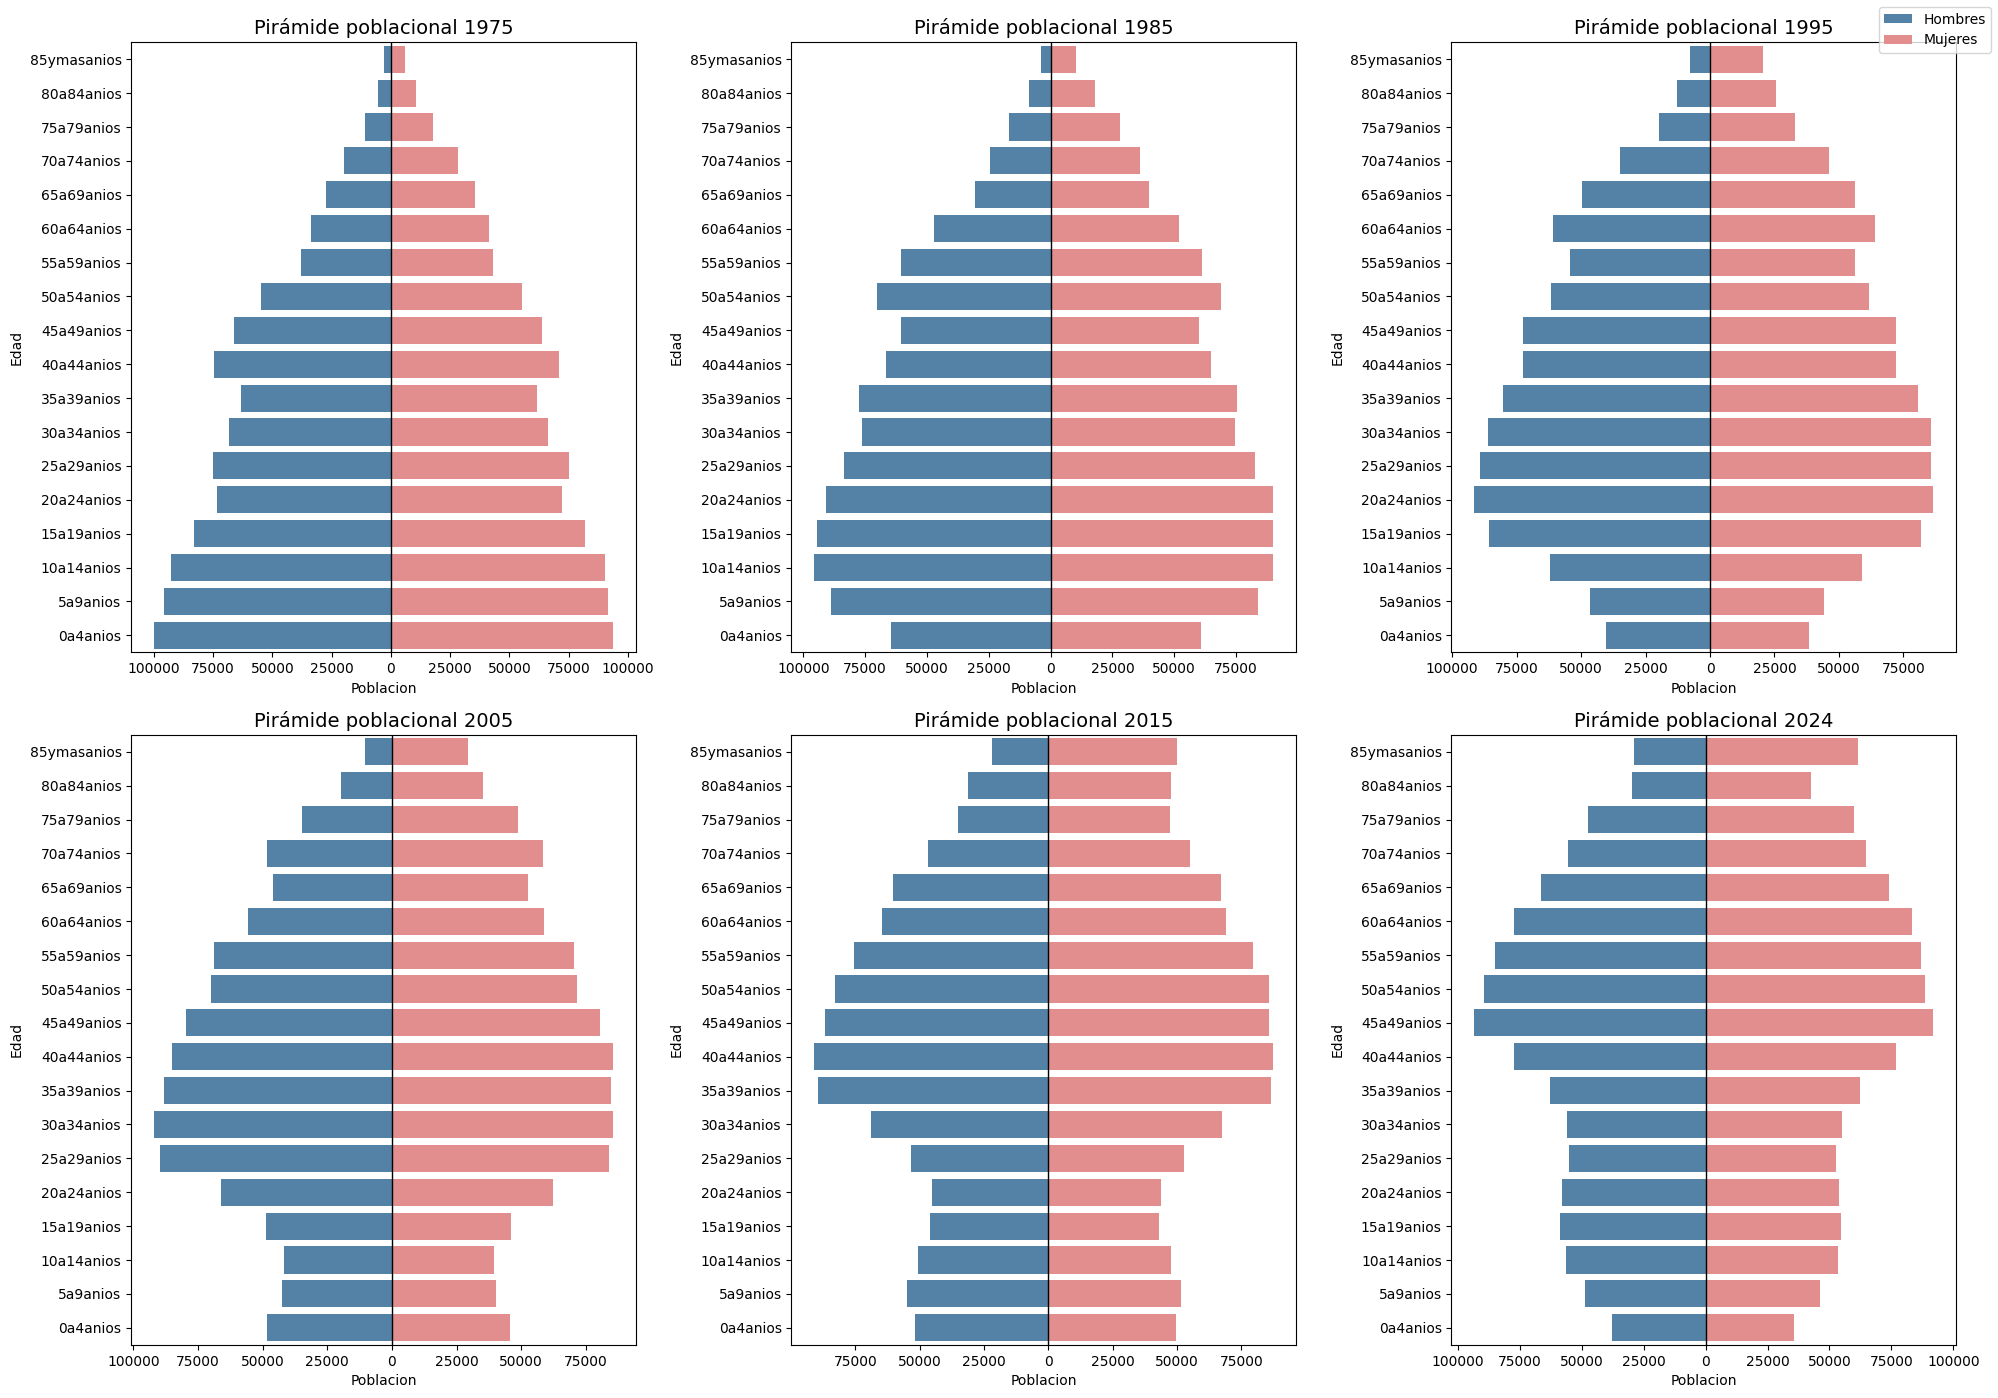

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# TRANSFORMAR EL DATASET
# -----------------------------

df_long = piramides.melt(
    id_vars="Parametros",
    var_name="Año",
    value_name="Poblacion"
)

# Extraer sexo
df_long["Sexo"] = df_long["Parametros"].apply(
    lambda x: "Hombres" if "Hombres" in x else "Mujeres"
)

# Extraer grupo de edad
df_long["Edad"] = df_long["Parametros"].str.split("_").str[-1]

# Convertir hombres a negativo
df_long.loc[df_long["Sexo"] == "Hombres", "Poblacion"] *= -1

# -----------------------------
# ORDEN CORRECTO DE EDADES
# (de jóvenes abajo a mayores arriba)
# -----------------------------

orden_edades = [
    "85ymasanios",
    "80a84anios",
    "75a79anios",
    "70a74anios",
    "65a69anios",
    "60a64anios",
    "55a59anios",
    "50a54anios",
    "45a49anios",
    "40a44anios",
    "35a39anios",
    "30a34anios",
    "25a29anios",
    "20a24anios",
    "15a19anios",
    "10a14anios",
    "5a9anios",
    "0a4anios",
]

# Convertir a categórica ordenada
df_long["Edad"] = pd.Categorical(
    df_long["Edad"],
    categories=orden_edades,
    ordered=True
)

# -----------------------------
# AÑOS A REPRESENTAR
# -----------------------------

años = ["1975", "1985", "1995", "2005", "2015", "2024"]

# -----------------------------
# CREAR SUBPLOTS
# -----------------------------

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

axes = axes.flatten()

for ax, año in zip(axes, años):

    data = df_long[df_long["Año"] == año]

    sns.barplot(
        data=data,
        x="Poblacion",
        y="Edad",
        hue="Sexo",
        dodge=False,
        palette={
            "Hombres": "steelblue",
            "Mujeres": "lightcoral"
        },
        ax=ax
    )

    # Línea central
    ax.axvline(0, color="black", linewidth=1)

    # Título
    ax.set_title(f"Pirámide poblacional {año}", fontsize=14)

    # Etiquetas positivas en eje X
    ticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(t)) for t in ticks])

    # Eliminar leyendas repetidas
    ax.legend().remove()

# Leyenda general
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()

plt.show()

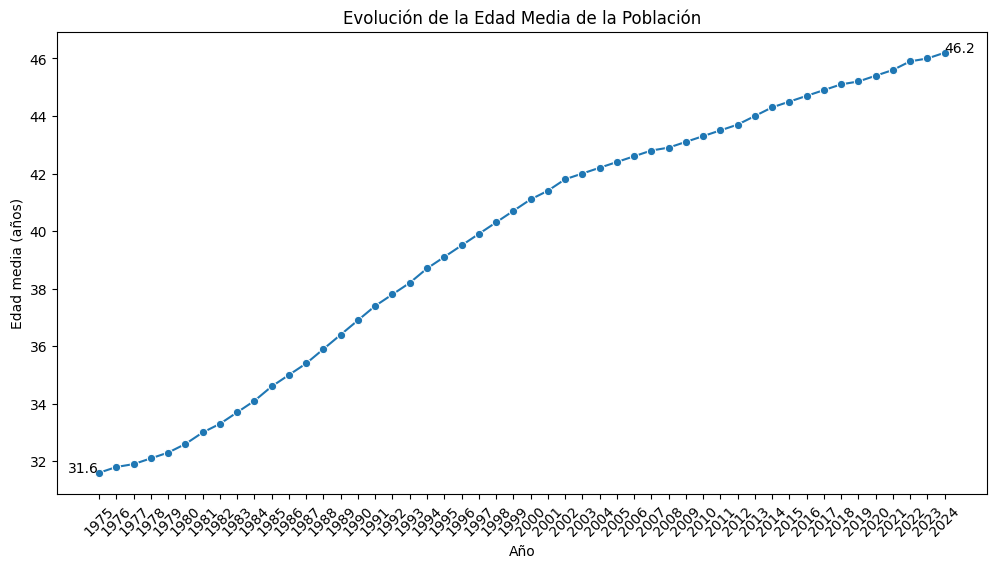

In [62]:

# Extraer fila 6
edad_media = ine_comp.iloc[6]

# Años
años = ine_comp.columns[1:]

# Valores
valores = edad_media[1:].astype(float)

# Crear gráfica
plt.figure(figsize=(12,6))

sns.lineplot(
    x=años,
    y=valores,
    marker="o"
)

# -----------------------------
# ETIQUETA PRIMER VALOR (1975)
# -----------------------------

plt.text(
    x=años[0],
    y=valores.iloc[0],
    s=round(valores.iloc[0], 2),
    ha='right'
)

# -----------------------------
# ETIQUETA ÚLTIMO VALOR (2024)
# -----------------------------

plt.text(
    x=años[-1],
    y=valores.iloc[-1],
    s=round(valores.iloc[-1], 2),
    ha='left'
)

# Títulos y ejes
plt.title("Evolución de la Edad Media de la Población")
plt.xlabel("Año")
plt.ylabel("Edad media (años)")

plt.xticks(rotation=45)

plt.show()

A la luz de los dos análisis realizados, y de las gráficas elaboradas, se puede concluir que la primera hipótesis planteada queda confirmada: en el periodo considerado (1975 a 2024) se ha producido un claro envejecimiento de la población, que se refleja tanto en la evolución de las pirámides de población, como en la edad media de la población, que se ha incrementado de forma sostenida durante el periodo, y pasa de 31,6 a 46,2 años de media.